[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning tweets...


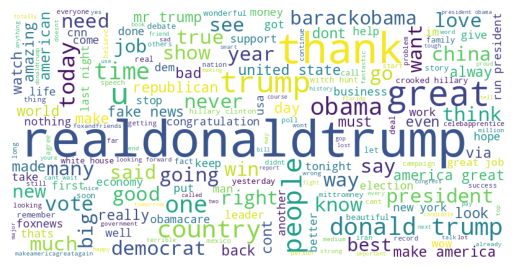

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1029/1029 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - accuracy: 0.8545 - loss: 0.3373 - val_accuracy: 0.8697 - val_loss: 0.3182
Epoch 2/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.9376 - loss: 0.1821 - val_accuracy: 0.9229 - val_loss: 0.2265
Epoch 3/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9581 - loss: 0.1252 - val_accuracy: 0.9185 - val_loss: 0.2334
Epoch 4/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9709 - loss: 0.0915 - val_accuracy: 0.9083 - val_loss: 0.3177
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      3639
           1       0.94      0.93      0.93      4586

    accuracy                           0.92      8225
   macro avg       0.92      0.92      0.92      8225
weighted avg       0.92      0.92      0.92      8225



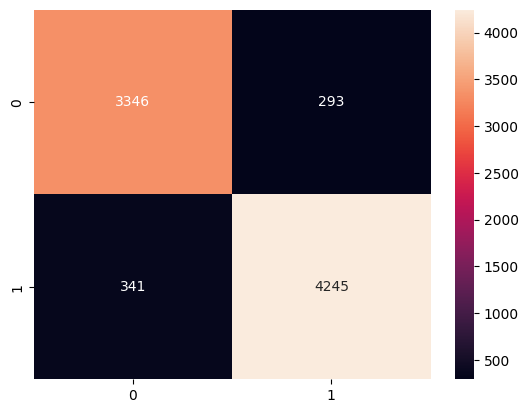

In [ ]:
# 1. Install and Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from textblob import TextBlob  # NEW

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


url = "/content/drive/MyDrive/AI/trumptweets_small.csv"
df = pd.read_csv(url)

# Use correct column
df = df[['content']]
df.columns = ['tweet']


def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    return 1 if polarity > 0 else 0

df['label'] = df['tweet'].apply(get_sentiment)

# ---------------------------------------------------------
# 4. Text Preprocessing
# ---------------------------------------------------------
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    text = " ".join([
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ])
    return text

print("Cleaning tweets...")
df['cleaned_tweet'] = df['tweet'].apply(clean_tweet)

# ---------------------------------------------------------
# 5. WordCloud
# ---------------------------------------------------------
all_words = ' '.join(df['cleaned_tweet'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# ---------------------------------------------------------
# 6. Tokenization
# ---------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_tweet'], df['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

max_length = int(np.percentile([len(x) for x in X_train_seq], 95))

X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

# ---------------------------------------------------------
# 7. LSTM Model
# ---------------------------------------------------------
model = Sequential([
    Embedding(10000, 128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---------------------------------------------------------
# 8. Training
# ---------------------------------------------------------
early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    X_train_padded, y_train,
    epochs=10,
    validation_data=(X_test_padded, y_test),
    callbacks=[early_stop],
    batch_size=32
)

# ---------------------------------------------------------
# 9. Evaluation
# ---------------------------------------------------------
y_pred = (model.predict(X_test_padded) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()